# Fig: Infotaxis vs MAP, mismatch agentLower scenario: pmax_th=0.95

Reference: 
- `20251230_fig_mismatch_agent_truth_efficiency_comparison.ipynb`

In [1]:
from pathlib import Path

import pandas as pd

import seaborn as sns

In [2]:
from plot_utils import bar_violinplot_success
from simulation_data_prep import get_success_fname

In [3]:
# Set path
path_data = Path("/Volumes/ssd_2tb_1/infotaxis_simu_2026")

path_fig = Path("../figs_paper_2026")

Samples: left:  926    right:  503
Mean:    left: 10.686  right: 13.674
Median:  left: 10.000  right: 13.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:  832    right:  476
Mean:    left: 11.019  right: 15.275
Median:  left: 10.000  right: 15.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:  618    right:  436
Mean:    left: 10.909  right: 15.546
Median:  left: 10.000  right: 14.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:  245    right:  253
Mean:    left: 8.886  right: 16.605
Median:  left: 7.000  right: 15.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------


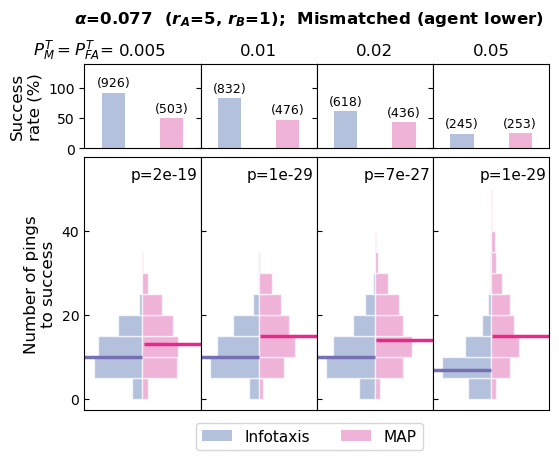

Samples: left:  890    right:  322
Mean:    left: 7.976  right: 11.373
Median:  left: 8.000  right: 11.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:  738    right:  313
Mean:    left: 8.289  right: 12.099
Median:  left: 8.000  right: 12.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:  460    right:  268
Mean:    left: 8.248  right: 13.317
Median:  left: 8.000  right: 13.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:  109    right:  117
Mean:    left: 6.697  right: 14.521
Median:  left: 6.000  right: 13.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------


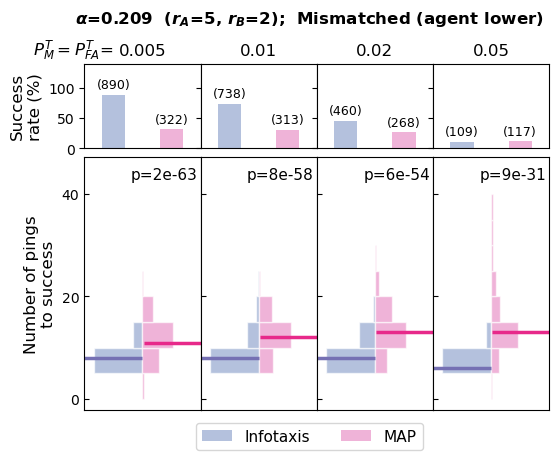

Samples: left:  886    right:  518
Mean:    left: 28.893  right: 39.925
Median:  left: 26.500  right: 36.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:  707    right:  455
Mean:    left: 29.253  right: 37.646
Median:  left: 27.000  right: 33.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:  344    right:  350
Mean:    left: 24.535  right: 36.280
Median:  left: 21.000  right: 30.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:   91    right:  120
Mean:    left: 11.286  right: 27.642
Median:  left: 9.000  right: 20.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------


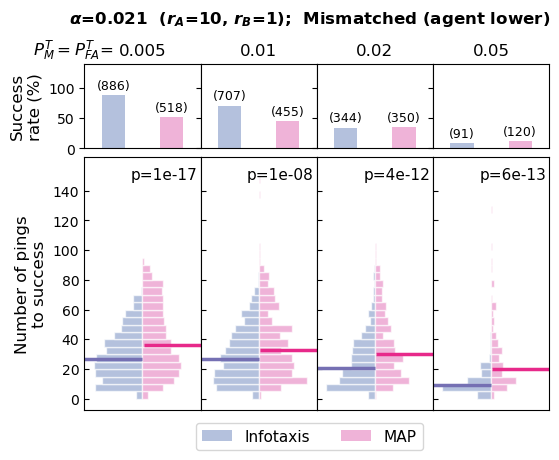

Samples: left:  862    right:  306
Mean:    left: 16.151  right: 22.350
Median:  left: 15.000  right: 22.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:  620    right:  278
Mean:    left: 16.834  right: 24.248
Median:  left: 16.000  right: 23.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:  265    right:  229
Mean:    left: 13.781  right: 29.424
Median:  left: 11.000  right: 27.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:   33    right:   41
Mean:    left: 8.455  right: 16.098
Median:  left: 8.000  right: 13.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------


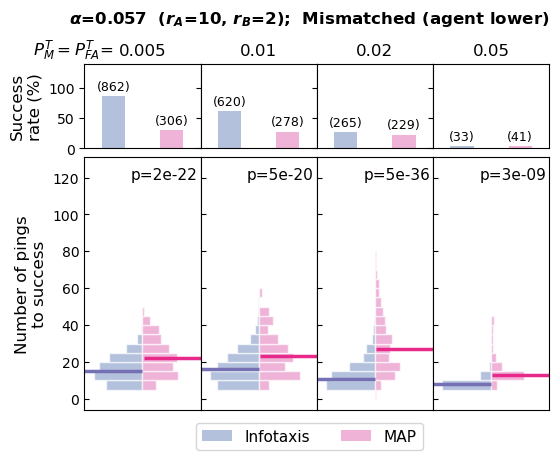

In [4]:
cr_all = [5, 10]
br_all = [1, 2]
pm_truth_all = [0.005, 0.01, 0.02, 0.05]
pm_agent_all = [0.001] * len(pm_truth_all)

for cr in cr_all:
    for br in br_all:

        path_left = path_data / "20260530_infotaxis_mismatch_agentLower_summary_compiled_pmax095_pmaxDiff1e-5"
        path_right = path_data / "20260530_MAP_mismatch_agentLower_summary_compiled_pmax095_pmaxDiff1e-5"
        pmax_th = 0.95
        pmax_diff_th = 1e-5

        df_x_all = []
        df_y_all = []
        for pm_agent, pm_truth in zip(pm_agent_all, pm_truth_all):
            # Load summary and ph details
            df_x = pd.read_csv(
                path_left / get_success_fname(
                    search_type="infotaxis", cr=cr, br=br, simulation_type="mismatch",
                    pmax_th=pmax_th, pmax_diff_th=pmax_diff_th,
                    pm_agent=pm_agent, pm_truth=pm_truth
                ), index_col=0
            )
            df_y = pd.read_csv(
                path_right / get_success_fname(
                    search_type="MAP", cr=cr, br=br, simulation_type="mismatch",
                    pmax_th=pmax_th, pmax_diff_th=pmax_diff_th,
                    pm_agent=pm_agent, pm_truth=pm_truth
                ), index_col=0
            )
            df_x_all.append(df_x)
            df_y_all.append(df_y)

        fig = bar_violinplot_success(
            cr=cr, br=br, pm_all=pm_truth_all,
            df_x_all=df_x_all, df_y_all=df_y_all,
            x_str="Infotaxis", y_str="MAP",
            stats_type="less",
            comparison_type="agent_lower",
            title_str_additional="Mismatched (agent lower)",
            colors=sns.color_palette("Set2"),
            colors_dark=sns.color_palette("Dark2"),
            color_idx_left=2, color_idx_right=3,
            alpha=0.65
        )

        fig.savefig(
            path_fig / f"fig_infotaxis_MAP_cmp_mismatch_agentLower_cr{cr}_br{br}_pmaxTh0.95_pmaxDiff1e-5.png",
            dpi=300, bbox_inches="tight"
        )